In [1]:
import numpy as np
#import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux, KerrEccEqFlux #trajectory module. KerrEccEqFlux used to generate p_at_plunge
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens

use_gpu = False #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself.

startup


In [2]:
#fixed parameters
T_LISA = 2 #0.1 #observation time, years. Should be 2.0 for actual runs.
dt = 10.0 #sampling interval, seconds

m1 = 1e6 #MBH mass in solar masses (source frame)
m2 = 10.0 #secondary mass in solar masses (source frame)
x0 = 1.0 #inclination, must be = 1.0 for equatorial model
p0_buffer = 1.0 #0.5 #while p0 will be determined by T_LISA assuming a plunging EMRI, the StableEMRIFisher code may not be suitable for plunge cases. We thus introduce this small buffer to extend the inspiral.

# initial phases
Phi_phi0 = 0.1 #azimuthal phase
Phi_theta0 = 0.2 #polar phase
Phi_r0 = 0.3 #radial phase

# define the extrinsic parameters
qK = np.pi / 5  # polar spin angle
phiK = np.pi / 6  # azimuthal viewing angle
qS = np.pi / 3  # polar sky angle
phiS = np.pi / 4  # azimuthal viewing angle
dist = 1.0  # distance in Gpc. We'll adjust this later to fix the SNR as SNR_fixed.
#distval=1.0*58.09 #Single value for Miaoxin
SNR_fixed = 40.0 #desired SNR throughout the grid. 

filename = f'sparse_grid' #filename
if not os.path.exists(filename):
    os.mkdir(filename)

filename_Fisher = f'Fishers' #subfolder where all the Fisher matrices will be stored.
filename_Fisher = os.path.join(filename,filename_Fisher)

calculate_Fishers = False #calculate Fisher matrices

SK_traj = EMRIInspiral(func=SuperKludgeFlux)
adiabatic_traj = EMRIInspiral(func=KerrEccEqFlux)

#set SK add_args here. This is where you remove/add pieces.
chi2 = 0.5 #dimensionless secondary spin
evolve_1PA = True #whether to include 1PA corrections.
evolve_primary = False #whether to include primary's evolution
evolve_2PA = True #whether to include 2PA corrections.
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]

In [3]:
#grid parameters over (a and e0)

N = 5 #no. of points along each axis

try:
    with h5py.File(f"{filename}/data.h5", "r") as f:
        param_grid = f["gridpoints"][:]  # Read the dataset into a NumPy array
        p_range = f["p0"][:] + p0_buffer #buffer
        
except FileNotFoundError:

    #choose parameter ranges here
    a_range = np.linspace(0.1,0.9,N)
    e_range = np.linspace(0.1,0.5,N) #choose wisely: eccentricity above 0.5 is extremely expensive already...
    
    # Generate the Cartesian product of all parameter values
    param_grid = np.array(list((product(a_range, e_range))))
    
    p_range = []
    for i in tqdm(range(len(param_grid))):
        a = param_grid[i,0]
        e0 = param_grid[i,1]

        #generate p0 using the adiabatic trajectory module instead of SK.
        p0 = get_p_at_t(traj_module=adiabatic_traj, t_out=T_LISA, traj_args=[m1, m2, a, e0, x0, Phi_phi0, Phi_theta0, Phi_r0])
        
        p_range.append(p0)

        #check p for plunge trajectories
        #t, p, e, x, pp, pt, pr = kerr_traj(m1, m2, a, p0, e0, x0, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T_LISA, dt=dt)
    
        #print(t[-1] - (T_LISA*YRSID_SI))
        
    p_range = np.array(p_range)

    print(param_grid.shape, p_range.shape)
    
    #save as an h5py file
    with h5py.File(f"{filename}/data.h5", "w") as f:
        f.create_dataset("gridpoints", data=param_grid)
        f.create_dataset("p0", data=p_range) #save plunging traj p0
        
    p_range += p0_buffer #buffer
    
    #with h5py.File(f"{filename}/p_e_grid_data.h5", "r") as f:
    #    loaded_data = f["dataset_name"][:]  # Read the dataset into a NumPy array
    
    #print(loaded_data)
    
    plt.scatter(param_grid[:,0],param_grid[:,1])
    plt.xlabel('a range',fontsize=16)
    plt.ylabel('e0 range',fontsize=16)
    plt.savefig(f"{filename}/grid.png",dpi=300,bbox_inches='tight')
    plt.show()

In [4]:
#initialize waveform model
sum_kwargs = {
    "pad_output": True, # True if you want waveforms always of the length of the LISA observation window (pads by zero if time-series is smaller). Recommended to be True if passing to SEF for near-plunge sources.
}

max_step_days = 5.0 #max trajectory step size in days. Smaller value leads to more stable trajectories, but takes longer to compute. Likely needs fiddling.

inspiral_kwargs = {
    "err":1e-11, #error tolerance in the DOPR integration routine. Default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}

waveform_model = GenerateEMRIWaveform(
            SuperKludgeWaveform, #the waveform class, see few.waveform.waveform.SuperKludgeWaveform
            sum_kwargs=sum_kwargs,
            inspiral_kwargs=inspiral_kwargs,
            return_list=False, #Must be False when interfacing with SEF: If ResponseWrapper provided, it automatically converts to lists. If GenerateEMRIWaveform supplied to SEF, it creates three equally-weighted copies as lists.
            )

#maybe good to add a window for smoothness?

#initialize LISA response model
tdi_gen ="2nd generation"# "1st generation"#

order = 20  # interpolation order (should not change the result too much)
tdi_kwargs_esa = dict(
    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
    order=order, 
    tdi=tdi_gen, 
    tdi_chan="AET",
)

index_lambda = 8 #azimuthal sky location (phiS)
index_beta = 7 #polar sky location (qS)

# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird

waveform_response = ResponseWrapper(
                        waveform_gen=waveform_model, #the waveform model around which to wrap the Response
                        Tobs=T_LISA,
                        t0=t0,
                        dt=dt,
                        index_lambda=index_lambda,
                        index_beta=index_beta,
                        flip_hx=True,  # set to True if waveform is h+ - ihx (FEW is)
                        use_gpu=use_gpu,
                        is_ecliptic_latitude=False,  # False if using polar angle (theta)
                        remove_garbage="zero",  # removes the beginning of the signal that has bad information
                        **tdi_kwargs_esa,
                        )

In [5]:
#noise model
channels = [A1TDISens, E1TDISens, T1TDISens] #AET TDI channels
noise_kwargs = [{"sens_fn": channel_i} for channel_i in channels] #Keyword argument for each channel to be supplied to get_sensitivity inside SEF

In [6]:
#calulating distances at each grid point such that SNR = some fixed value.

#setup SEF
param_names = ['m1','m2','a','chi2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0'] #parameters to be varied at each grid point.

add_param_args = {'chi2':chi2,
                  '1PA':evolve_1PA,
                  'evolve_primary':evolve_primary,
                  '2PA':evolve_2PA} #dict of parameters NOT included by default in SEF. This contains the additional SK parameters. 

sef_kwargs = {'EMRI_waveform_gen':waveform_response, #EMRI waveform model with TDI response.
              'param_names': param_names, #params to be varied
              'der_order':4, #derivative order. Available options: 2, 4, 6, 8
              'Ndelta':12, #number of stable points, can be any integer.
              'stats_for_nerds': False, #true if you wanna print debugging info
              'stability_plot': False, #true if you wanna plot stability surfaces
              'use_gpu':use_gpu,
              'filename': filename_Fisher, #filename where Fishers to be stored
              'noise_model':get_sensitivity,
              'channels':channels,
              'noise_kwargs':noise_kwargs,
              'add_param_args':add_param_args,
              'plunge_check':False, #save time by avoiding internal check for plunging trajectories (this is ensured by our choice of p0)
             }

emri_kwargs = {'T': T_LISA, 'dt': dt}

try: #dist ranges, fmax already available?
    with h5py.File(f"{filename}/data.h5", "r") as f:
        dist_range = f["dists"][:]  # Read the dataset into a NumPy array
        fmax_range = f["fmax"][:]

except:
    
    dist_range = []
    fmax_range = []
    
    for i in tqdm(range(len(param_grid))):
        a = param_grid[i][0]
        e0 = param_grid[i][1]
        p0 = p_range[i]
    
        param_list = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

        wave = waveform_response(*param_list, *add_args, **emri_kwargs)

        PSD = generate_PSD(wave, dt, noise_PSD = get_sensitivity, channels = channels, noise_kwargs = noise_kwargs, use_gpu = use_gpu)

        #adapted from Lorenzo's FoM code
        t, p, e, x, Phi_phi, Phi_r, Phi_theta = adiabatic_traj(m1, m2, a, p0, e0, x0, dt=1e-5, T=T_LISA, integrate_backwards=False)
        p_back = p[::-1]
        e_back = e[::-1]
        x_back = x[::-1]
        
        omegaPhi, omegaTheta, omegaR = get_fundamental_frequencies(a, p_back, e_back, x_back)
        dimension_factor = 2.0 * np.pi * m1 * MTSUN_SI
        omegaPhi = omegaPhi / dimension_factor
        omegaTheta = omegaTheta / dimension_factor
        omegaR = omegaR / dimension_factor
        
        # define frequency ranges for inner product
        ns = waveform_response.waveform_gen.waveform_generator.ns
        ms = waveform_response.waveform_gen.waveform_generator.ms
        ls = waveform_response.waveform_gen.waveform_generator.ls

        if use_gpu:
            ns = ns.get()
            ms = ms.get()
            ls = ls.get()
            
        max_f = float(np.max(np.abs(omegaPhi[None,:] * ms[:,None] + omegaR[None,:] * ns[:,None])))

        sef_kwargs['fmax'] = max_f
        
        #calculate Fisher
        sef = StableEMRIFisher(*param_list, **emri_kwargs, **sef_kwargs)
        SNR_before = sef.SNRcalc_SEF()
        dist_fact = SNR_before/SNR_fixed #adjust distance such that SNR = SNR_fixed
        
        param_list[6] *= dist_fact
        dist_range.append(dist*dist_fact)
        fmax_range.append(max_f)
    
        del sef #memory management. Not sure if this is actually helpful.
    
        sef = StableEMRIFisher(*param_list, **emri_kwargs, **sef_kwargs)
        SNR_after = sef.SNRcalc_SEF()
    
        print("SNR before: ", SNR_before, "SNR_after: ", SNR_after)
    
    #save as an h5py file
    with h5py.File(f"{filename}/data.h5", "a") as f: #"a" flag for appending existing data file.
        f.create_dataset("dists", data=np.array(dist_range))
        f.create_dataset("fmax", data=np.array(fmax_range))

In [197]:
def fishertransform(Fisher, m1, m2, chi2, index_of_m1 = 0, index_of_m2 = 1, index_of_chi2 = 3):
    """ transform m1, m2 -> ln m1, ln m2. Fisher transformation: https://en.wikipedia.org/wiki/Fisher_information """
    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    J[index_of_m2,index_of_m2] = m2
    J[index_of_chi2, index_of_chi2] = 1

    return J.T@Fisher@J

#evaluating and saving the Fisher matrices along the grid
for i in tqdm(range(len(param_grid))):

    try:
        #skip Fisher calculation for ones already calculated
        with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
            _ = f["Fisher"][:]

    except FileNotFoundError:
        a = param_grid[i][0]
        e0 = param_grid[i][1]
        p0 = p_range[i]
        dist = dist_range[i]
        fmax = fmax_range[i]

        sef_kwargs['suffix'] = i #add a suffix to the Fisher filename
        sef_kwargs['fmax'] = fmax
        
        param_list = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

        #calculate Fisher
        sef = StableEMRIFisher(*param_list, **emri_kwargs, **sef_kwargs)
        sef() #execute SEF for Fisher calculation

for i in tqdm(range(len(param_grid))):

    #once Fishers calculated (in m1, m2 parametrization), transform to log-masses for numerical stability
    with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
        Fisher = f["Fisher"][:]

    Fisher_transformed = fishertransform(Fisher, m1, m2, chi2)

    with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "w") as f:
        f.create_dataset("Fisher", data = Fisher)
        f.create_dataset("Fisher_transformed", data = Fisher_transformed)

100%|██████████████████████████████████████████| 25/25 [00:00<00:00, 534.70it/s]


In [198]:
np.linalg.eigvals(Fisher_transformed)

array([7.08147388e+15, 3.29968012e+13, 1.23020292e+12, 5.32961482e+09,
       4.29715359e+06, 6.61765400e+04, 3.21626205e+04, 1.77337085e+03,
       8.03617839e+02, 4.18381658e+02, 2.48481968e+02, 8.23927329e+01,
       5.62680985e-03])

In [199]:
#check Positive Semi-Definiteness of the transformed Fisher Matrices

print("Checking transformed Fisher positive-definiteness...")

check_flag = True

params_to_remove = []

for i in tqdm(range(len(param_grid))):

    with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
        Fisher = f["Fisher"][:]

    with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
        Fisher_transformed = f["Fisher_transformed"][:]

    #if you want to exclude sus parameters for troubleshooting
    rows_to_remove = []
    for j in range(len(param_names)):
        if param_names[j] in params_to_remove:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

    rows_to_remove = np.array(rows_to_remove)
    
    if len(rows_to_remove) > 0:
        Fisher_transformed = np.delete(np.delete(Fisher_transformed,rows_to_remove,axis=0),rows_to_remove,axis=1)
        Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

    if (np.linalg.eigvals(Fisher_transformed) < 0.0).any():
        check_flag = False
        raise ValueError('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")

Checking transformed Fisher positive-definiteness...


100%|██████████████████████████████████████████| 25/25 [00:00<00:00, 625.68it/s]

positive-definiteness check passed!


In [200]:
information = []

params_to_remove = []

for i in tqdm(range(len(param_grid))):

    with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
        Fisher = f["Fisher"][:]
        Fisher_transformed = f["Fisher_transformed"][:]

    #if you want to exclude sus parameters for troubleshooting
    rows_to_remove = []
    for j in range(len(param_names)):
        if param_names[j] in params_to_remove:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

    rows_to_remove = np.array(rows_to_remove)
    
    if len(rows_to_remove) > 0:
        Fisher_transformed = np.delete(np.delete(Fisher_transformed,rows_to_remove,axis=0),rows_to_remove,axis=1)
        Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

    information.append(np.sqrt(Fisher_transformed[3,3]))
    
information = np.asarray(information)

100%|█████████████████████████████████████████| 25/25 [00:00<00:00, 1282.40it/s]


In [126]:
print(information.shape)

(25,)


/tmp/ipykernel_18148/542771665.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


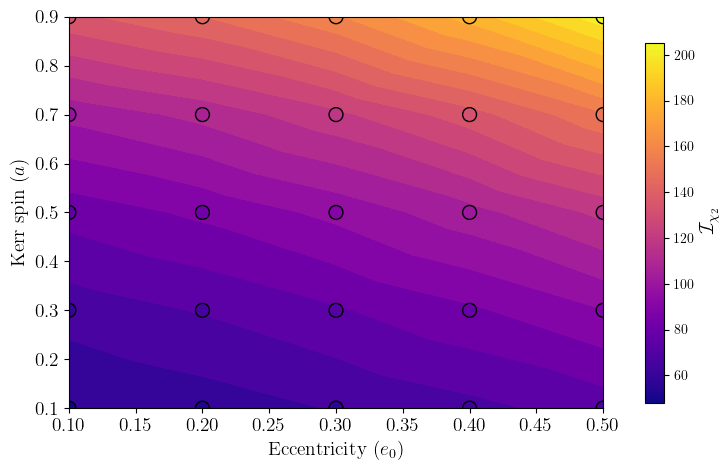

In [145]:
#information plot

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]

label_fontsize = 14
tick_fontsize = 14
title_fontsize = 16

a_vals=param_grid[:, 0]
e_vals=param_grid[:, 1]

fig, axes = plt.subplots() 

# scatter plot
axes.tricontourf(e_vals, a_vals, information, cmap = 'plasma', levels = 20)
scatter1 = axes.scatter(e_vals,a_vals, c = information, cmap='plasma', s = 100, rasterized=True, edgecolor='k')
axes.set_xlabel(r'Eccentricity ($e_0$)', fontsize=label_fontsize)
axes.set_ylabel(r'Kerr spin ($a$)', fontsize=label_fontsize)
    
axes.tick_params(axis='both', which='major', labelsize=tick_fontsize)
#fig.colorbar(scatter1, ax=axes)

# add colorbar on its own axes
cbar_ax = plt.gcf().add_axes([1.015, 0.15, 0.03, 0.75])
cbar = plt.colorbar(scatter1,cax=cbar_ax)
cbar.set_label(r'$\mathcal{I}_{\chi_2}$', fontsize=14)

plt.tight_layout()

plt.savefig(f'{filename}/chi2_information.png', dpi=300, bbox_inches='tight')
    
plt.show()

In [208]:
#inverting the Fisher information matrix and saving the std on chi2 (after regularization)

std = []

#indices_converged = []

params_to_remove = ['m1','m2']

for i in tqdm(range(len(param_grid))):

    with h5py.File(f"{filename_Fisher}/Fisher_{i}.h5", "r") as f:
        Fisher = f["Fisher"][:]
        Fisher_transformed = f["Fisher_transformed"][:]
    
    #if you want to exclude sus parameters for troubleshooting
    rows_to_remove = []
    for j in range(len(param_names)):
        if param_names[j] in params_to_remove:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

    rows_to_remove = np.array(rows_to_remove)
    
    if len(rows_to_remove) > 0:
        Fisher_transformed = np.delete(np.delete(Fisher_transformed,rows_to_remove,axis=0),rows_to_remove,axis=1)
        Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

    cov0 = np.linalg.inv(Fisher_transformed)

    print(np.diag(cov0@Fisher_transformed), max(np.linalg.eigvals(cov0))/min(np.linalg.eigvals(cov0)))
    
    #print(np.abs(1-np.linalg.det(np.dot(Fisher_transformed,cov0)))/len(cov0))
    
    """
    #correcting for inverse errors
    epsilon = np.abs(1-np.linalg.det(np.dot(Fisher_transformed,cov0)))/len(cov0)
    
    count = 0
    tol = 1e-12
    max_iter = 1e6

    print(epsilon)

    print("condition number before: ", max(np.linalg.eigvals(cov0))/min(np.linalg.eigvals(cov0)))
    
    while (epsilon > tol) & (count < max_iter):
        
        count += 1
        
        #print("regularization factor: ", epsilon)

        cov0 += epsilon * np.diag(np.diag(cov0))
        
        epsilon = np.abs(1 - np.linalg.det(np.dot(cov0,np.linalg.inv(cov0)))) / len(cov0)
    
    print(f"epsilon = {epsilon} after {count} regularization iterations.")
    print("condition number after: ", max(np.linalg.eigvals(cov0))/min(np.linalg.eigvals(cov0)))
    
    if count == max_iter:
        print("not converged. rejecting point.")

    elif count < max_iter:
        indices_converged.append(i)
    """
    
    std.append(np.sqrt(np.float64(cov0[1,1]))) #chi2 variance

std = np.asarray(std)
#param_grid_converged = param_grid[indices_converged]

100%|█████████████████████████████████████████| 25/25 [00:00<00:00, 1028.45it/s]

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 5499611699170472.0
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 1.5144302464913628e+16
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 3.882640208371867e+16
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 9.475044179028275e+16
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 2.419137478706965e+17
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 6247374680132485.0
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 1.48672943069158e+16
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 3.2611285993489908e+16
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 6.352649413962596e+16
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 1.2192567763536013e+17
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 4250958127430038.5
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 8877044789677422.0
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 1.743031304974876e+16
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 3.017308926650594e+16
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 4.965117738261365e+16
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 1133336441309585.5
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 2206915521333997.5
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 420050188407

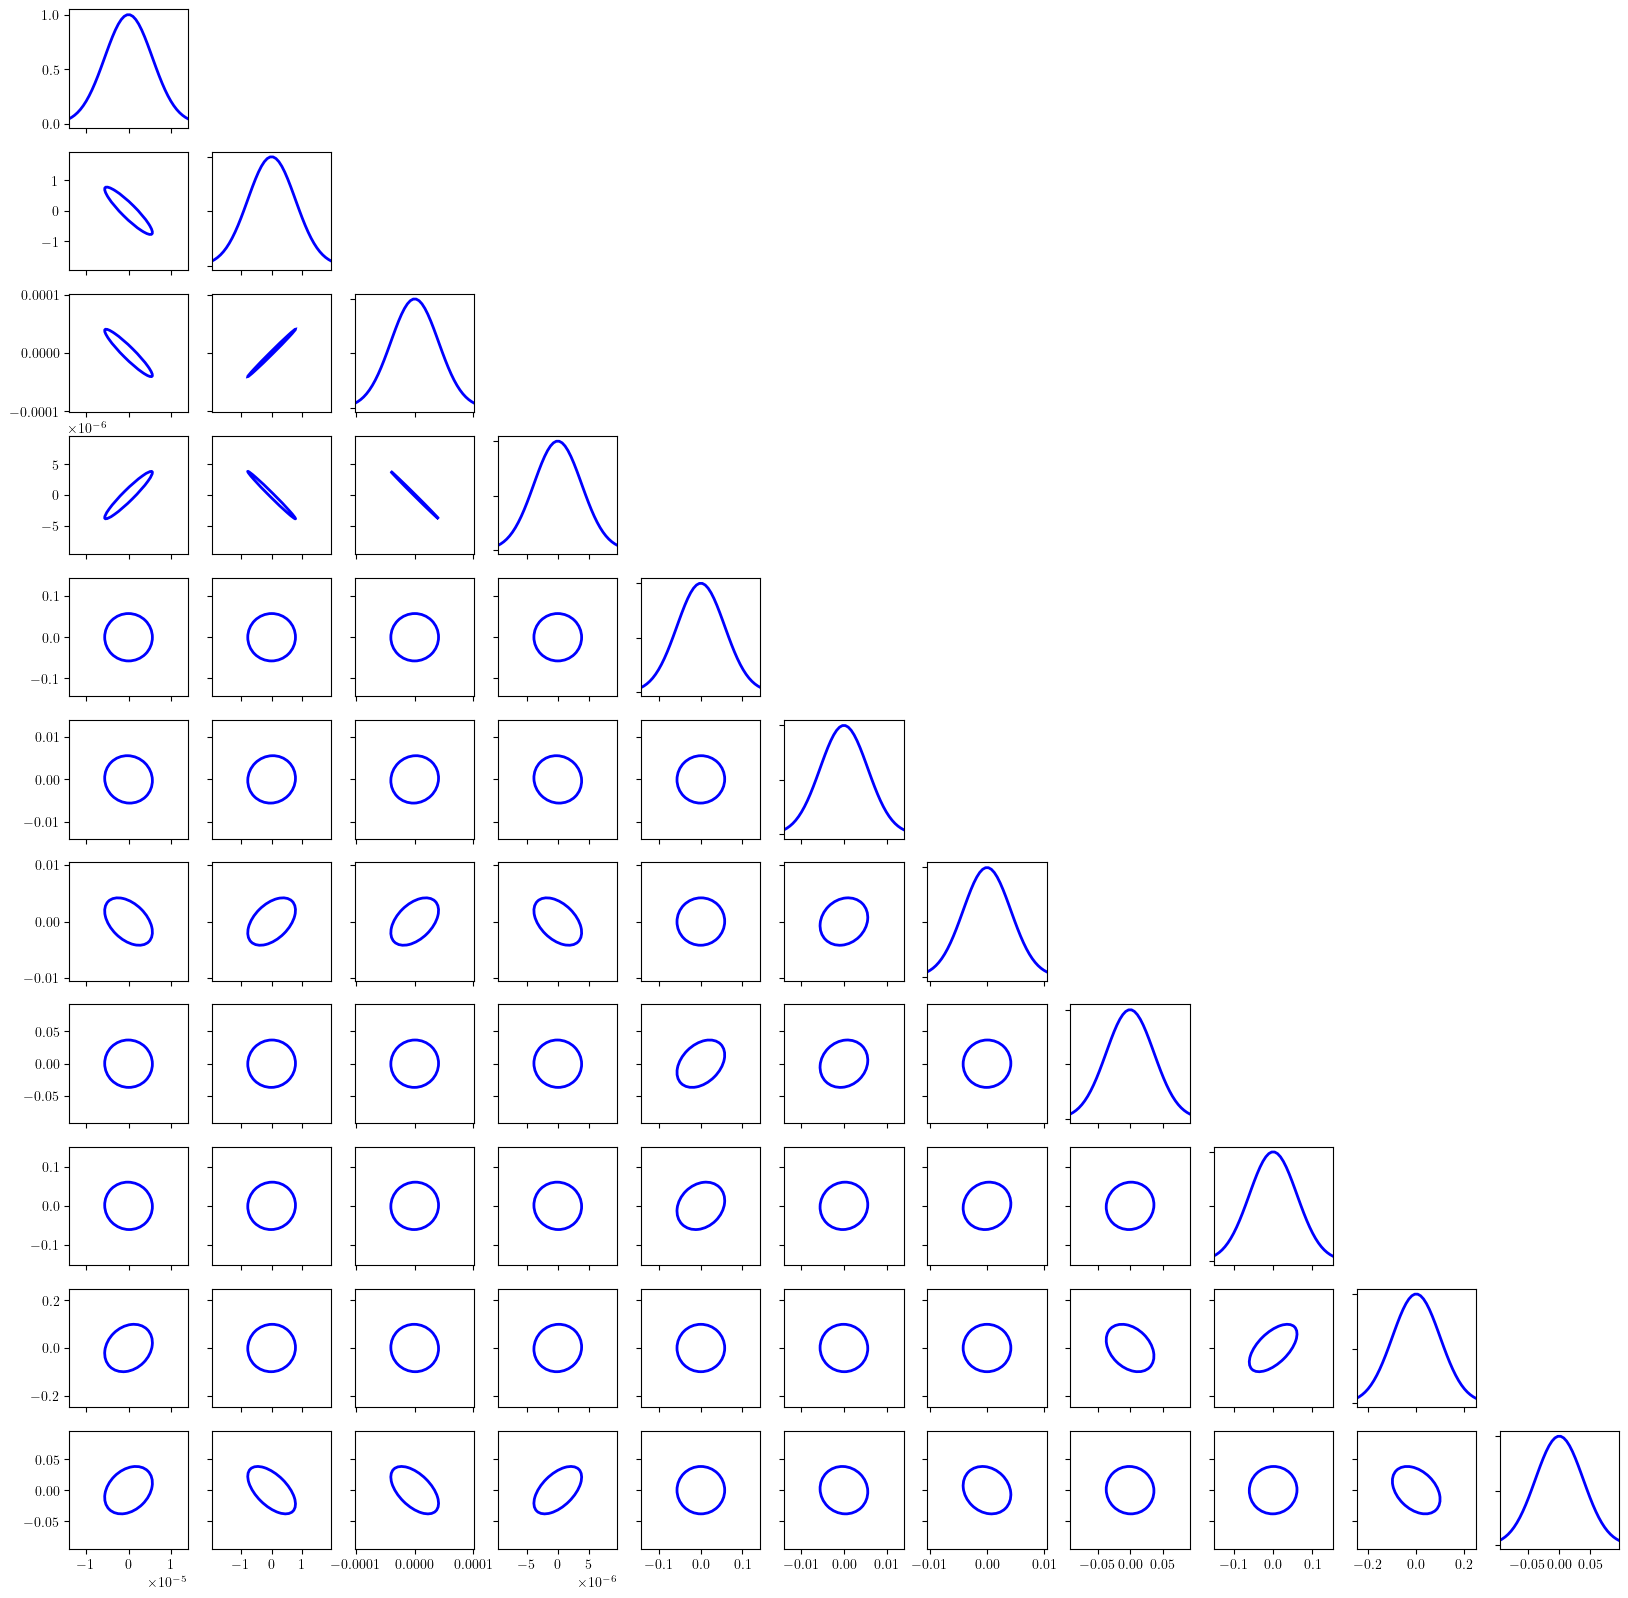

In [209]:
from stableemrifisher.plot import CovEllipsePlot

fig, axs = CovEllipsePlot(cov0)

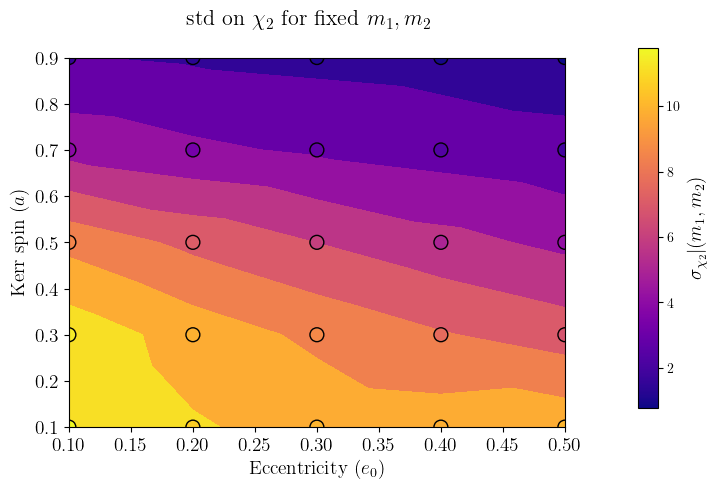

In [210]:
#variance plot

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]

label_fontsize = 14
tick_fontsize = 14
title_fontsize = 16

a_vals=param_grid[:, 0]
e_vals=param_grid[:, 1]

fig, axes = plt.subplots() 

mask = std < 10000

# scatter plot
axes.tricontourf(e_vals[mask], a_vals[mask], std[mask], cmap = 'plasma', levels = 10)
scatter1 = axes.scatter(e_vals[mask], a_vals[mask], c = std[mask], cmap='plasma',rasterized=True, edgecolor='k', s = 100)
axes.set_xlabel(r'Eccentricity ($e_0$)', fontsize=label_fontsize)
axes.set_ylabel(r'Kerr spin ($a$)', fontsize=label_fontsize)
    
axes.tick_params(axis='both', which='major', labelsize=tick_fontsize)
#fig.colorbar(scatter1, ax=axes)

# add colorbar on its own axes
cbar_ax = plt.gcf().add_axes([1.015, 0.15, 0.03, 0.75])
cbar = plt.colorbar(scatter1,cax=cbar_ax)
cbar.set_label(r'$\sigma_{\chi_2} | (m_1, m_2)$', fontsize=14)

#plt.tight_layout()
plt.suptitle(r"std on $\chi_2$ for fixed $m_1, m_2$", fontsize = 16)
plt.savefig(f'{filename}/chi2_std.png', dpi=300, bbox_inches='tight')
    
plt.show()